In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from keras.models import Sequential
from keras.layers import Dense, MaxPooling2D, Conv2D, UpSampling2D
from sklearn.model_selection import train_test_split

In [3]:
import os
from PIL import Image

# Input and output folders
input_folder = r"C:\Users\maila\Desktop\Python\DL - FLow\7. Auto Encoders\my_images"
output_folder = r"C:\Users\maila\Desktop\Python\DL - FLow\7. Auto Encoders\gray_image"

# Create output folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Process all images
for filename in os.listdir(input_folder):

    # Process only image files
    if filename.lower().endswith((".jpg", ".jpeg", ".png")):

        input_path = os.path.join(input_folder, filename)
        output_path = os.path.join(output_folder, filename)

        # Open image and convert to grayscale
        image = Image.open(input_path).convert("L")

        # Save with the same filename
        image.save(output_path)

        # print(f"Converted: {filename}")

print("\nAll images converted successfully!")
print(f"Grayscale images saved in: {output_folder}")


All images converted successfully!
Grayscale images saved in: C:\Users\maila\Desktop\Python\DL - FLow\7. Auto Encoders\gray_image


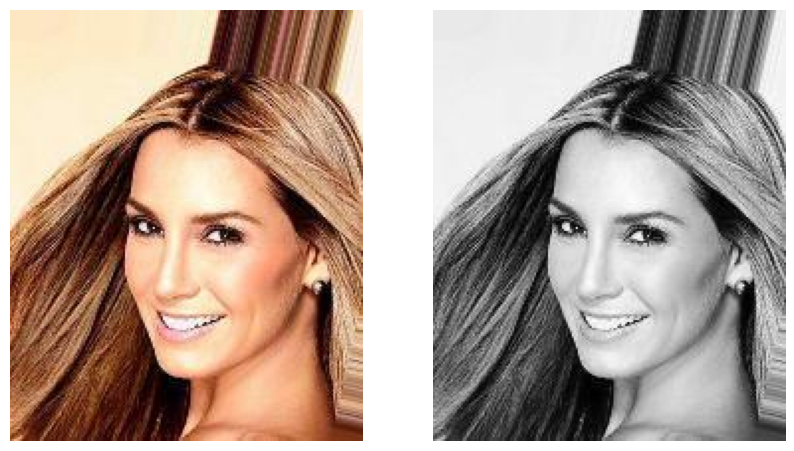

In [4]:
import matplotlib.pyplot as plt
from PIL import Image

original_image = r"C:\Users\maila\Desktop\Python\DL - FLow\7. Auto Encoders\my_images\000001.jpg"
gray_image = r"C:\Users\maila\Desktop\Python\DL - FLow\7. Auto Encoders\gray_image\000001.jpg"

# Load the images
original = Image.open(original_image)
gray = Image.open(gray_image)

fig, axs= plt.subplots(1, 2, figsize=(10, 10))
# Display original image
axs[0].imshow(original)
axs[0].axis("off")

# Display grayscale image
axs[1].imshow(gray, cmap="gray")
axs[1].axis("off")

plt.show()

In [5]:
from PIL import Image
import os

# Existing folders
color_folder = r"C:\Users\maila\Desktop\Python\DL - FLow\7. Auto Encoders\my_images"
gray_folder = r"C:\Users\maila\Desktop\Python\DL - FLow\7. Auto Encoders\gray_image"

# Target size
image_size = (64, 64)

# Resize color images
for filename in os.listdir(color_folder):

    if filename.lower().endswith((".jpg", ".jpeg", ".png")):

        path = os.path.join(color_folder, filename)

        image = Image.open(path)
        image = image.resize(image_size, Image.Resampling.LANCZOS)

        # Replace original image
        image.save(path)

        #print("Resized color:", filename)


# Resize grayscale images
for filename in os.listdir(gray_folder):

    if filename.lower().endswith((".jpg", ".jpeg", ".png")):

        path = os.path.join(gray_folder, filename)

        image = Image.open(path)
        image = image.resize(image_size, Image.Resampling.LANCZOS)

        # Replace original image
        image.save(path)

        #print("Resized gray:", filename)

print("\nAll images resized to 64 × 64 and replaced.")


All images resized to 64 × 64 and replaced.


In [6]:
model=Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 1)))
model.add(MaxPooling2D((2, 2), padding='same'))
model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2), padding='same'))
model.add(Conv2D(8, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2), padding='same'))

model.add(Conv2D(8, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(16, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(UpSampling2D((2, 2)))
model.add(Conv2D(3, (3, 3), activation='sigmoid', padding='same'))


c:\Users\maila\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 8, 8, 8)        │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,363 (52.20 KB)

 Trainable params: 13,363 (52.20 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
import os
import numpy as np
from PIL import Image

gray_folder = r"C:\Users\maila\Desktop\Python\DL - FLow\7. Auto Encoders\gray_image"
color_folder = r"C:\Users\maila\Desktop\Python\DL - FLow\7. Auto Encoders\my_images"

X = []
y = []

# Get filenames from grayscale folder
filenames = sorted(os.listdir(gray_folder))

for filename in filenames:

    if filename.lower().endswith((".jpg", ".jpeg", ".png")):

        # Paths
        gray_path = os.path.join(gray_folder, filename)
        color_path = os.path.join(color_folder, filename)

        # Read grayscale image
        gray_image = Image.open(gray_path).convert("L")

        # Read original color image
        color_image = Image.open(color_path).convert("RGB")

        # Convert images to NumPy arrays
        gray_array = np.array(gray_image)
        color_array = np.array(color_image)

        # Normalize pixel values from [0, 255] to [0, 1]
        gray_array = gray_array / 255.0
        color_array = color_array / 255.0

        # Add to X and y
        X.append(gray_array)
        y.append(color_array)

# Convert lists to NumPy arrays
X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("X pixel range:", X.min(), "to", X.max())
print("y pixel range:", y.min(), "to", y.max())

X shape: (21986, 64, 64)
y shape: (21986, 64, 64, 3)
X pixel range: 0.0 to 1.0
y pixel range: 0.0 to 1.0


In [9]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((17588, 64, 64), (4398, 64, 64), (17588, 64, 64, 3), (4398, 64, 64, 3))

In [11]:
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['accuracy', 'mae'])

In [12]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [13]:
history=model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), callbacks=[early_stopping])

Epoch 1/100
550/550 ━━━━━━━━━━━━━━━━━━━━ 23s 34ms/step - accuracy: 0.7438 - loss: 0.0223 - mae: 0.1091 - val_accuracy: 0.7436 - val_loss: 0.0161 - val_mae: 0.0921
Epoch 2/100
550/550 ━━━━━━━━━━━━━━━━━━━━ 19s 32ms/step - accuracy: 0.7385 - loss: 0.0149 - mae: 0.0878 - val_accuracy: 0.7365 - val_loss: 0.0147 - val_mae: 0.0868
Epoch 3/100
550/550 ━━━━━━━━━━━━━━━━━━━━ 18s 32ms/step - accuracy: 0.7401 - loss: 0.0138 - mae: 0.0837 - val_accuracy: 0.7490 - val_loss: 0.0137 - val_mae: 0.0836
Epoch 4/100
550/550 ━━━━━━━━━━━━━━━━━━━━ 17s 31ms/step - accuracy: 0.7424 - loss: 0.0132 - mae: 0.0815 - val_accuracy: 0.7439 - val_loss: 0.0131 - val_mae: 0.0811
Epoch 5/100
550/550 ━━━━━━━━━━━━━━━━━━━━ 56s 101ms/step - accuracy: 0.7438 - loss: 0.0127 - mae: 0.0799 - val_accuracy: 0.7358 - val_loss: 0.0127 - val_mae: 0.0793
Epoch 6/100
550/550 ━━━━━━━━━━━━━━━━━━━━ 35s 64ms/step - accuracy: 0.7435 - loss: 0.0124 - mae: 0.0789 - val_accuracy: 0.7337 - val_loss: 0.0125 - val_mae: 0.0789
Epoch 7/100
550/550 ━

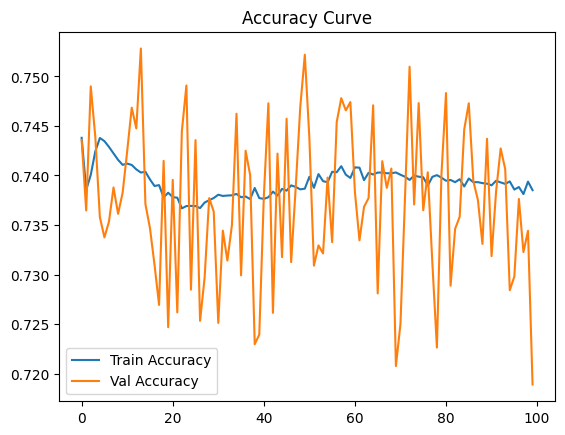

In [14]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Curve")
plt.legend()
plt.show()

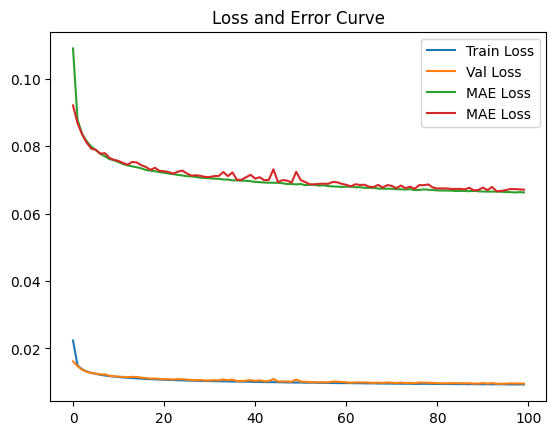

In [15]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.plot(history.history['mae'], label='MAE Loss')
plt.plot(history.history['val_mae'], label='MAE Loss')
plt.title("Loss and Error Curve")
plt.legend()
plt.show()

In [16]:
model.save("Colourization_model.keras")

Input shape: (1, 64, 64, 1)
Pixel range: 0.0196078431372549 to 0.9137254901960784
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step
Output shape: (1, 64, 64, 3)


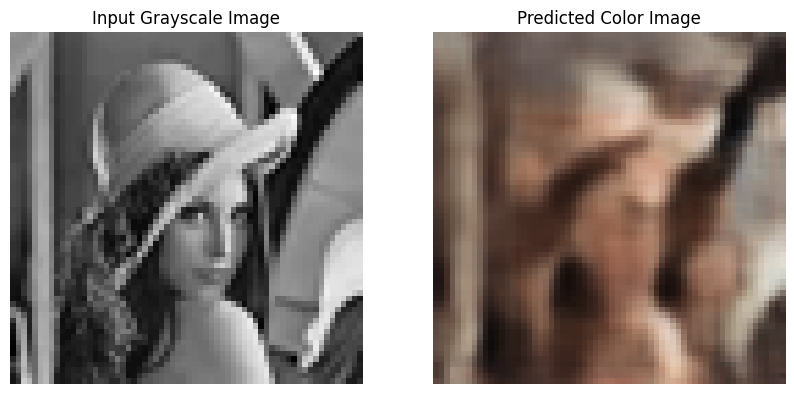

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Path of test image
image_path = r"C:\Users\maila\Desktop\Python\DL - FLow\7. Auto Encoders\Test_images.jpg"

# Load grayscale image
image = Image.open(image_path).convert("L")

# Resize to 64x64
image = image.resize((64, 64))

# Convert to NumPy array
image_array = np.array(image)

# Normalize pixel values from [0, 255] to [0, 1]
image_array = image_array / 255.0

# Add channel dimension
# (64, 64) -> (64, 64, 1)
image_array = np.expand_dims(image_array, axis=-1)

# Add batch dimension
# (64, 64, 1) -> (1, 64, 64, 1)
X_test_image = np.expand_dims(image_array, axis=0)

print("Input shape:", X_test_image.shape)
print("Pixel range:", X_test_image.min(), "to", X_test_image.max())

# Pass image through model
predicted_image = model.predict(X_test_image)

print("Output shape:", predicted_image.shape)

# Remove batch dimension
predicted_image = predicted_image[0]

# Display input and model output
plt.figure(figsize=(10, 5))

# Grayscale input
plt.subplot(1, 2, 1)
plt.imshow(image_array.squeeze(), cmap="gray")
plt.title("Input Grayscale Image")
plt.axis("off")

# Predicted color image
plt.subplot(1, 2, 2)
plt.imshow(predicted_image)
plt.title("Predicted Color Image")
plt.axis("off")

plt.show()